# EDA — Customer Churn

Esta etapa tem como objetivo explorar visualmente os principais padrões relacionados ao cancelamento de clientes.

A análise será realizada sobre a base tratada gerada na etapa de Data Cleaning.

Serão utilizados gráficos e análises descritivas para identificar segmentos com maior concentração de churn e levantar hipóteses para o negócio.

In [1]:
# Importar bibliotecas

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Carregar a base tratada

df = pd.read_csv("../data/processed/customer_churn_clean.csv")

In [3]:
# Validação

df.shape

(7043, 21)

## 1. Distribuição do Churn

Antes de analisar os diferentes segmentos de clientes, vamos compreender a distribuição geral da variável-alvo.

A taxa de churn representa a proporção de clientes que cancelaram o serviço na base analisada.

In [ ]:
# Taxa de Churn

df["Churn"].value_counts(normalize=True).mul(100).round(2)

Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64

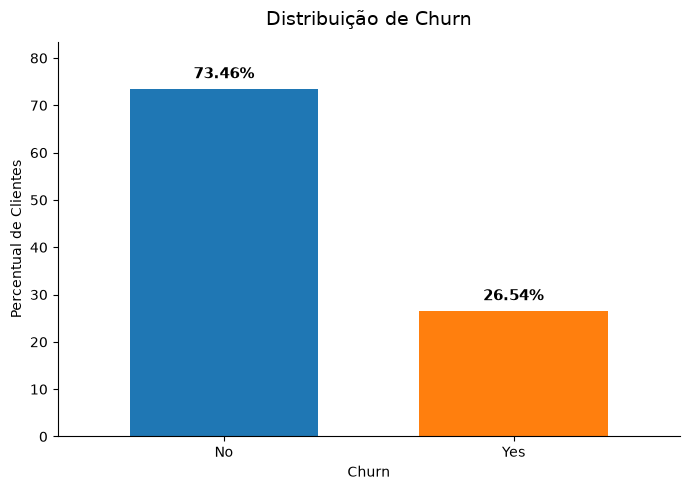

In [9]:
# Gráfico de portfólio

churn_pct = (
    df["Churn"]
    .value_counts(normalize=True)
    .mul(100)
)

cores = ["#1f77b4", "#ff7f0e"]

ax = churn_pct.plot(
    kind="bar",
    figsize=(7, 5),
    color=cores,
    width=0.65
)

ax.set_title(
    "Distribuição de Churn",
    fontsize=14,
    pad=12
)

ax.set_xlabel("Churn")
ax.set_ylabel("Percentual de Clientes")
ax.tick_params(axis="x", rotation=0)

# Espaço superior para os rótulos
ax.set_ylim(0, churn_pct.max() + 10)

# Percentuais sobre as barras
for i, valor in enumerate(churn_pct):
    ax.text(
        i,
        valor + 1.5,
        f"{valor:.2f}%",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

# Remove as linhas superior e direita
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## 2. Churn por Tipo de Contrato

O tipo de contrato é uma das principais características associadas ao cancelamento de clientes.

Nesta análise, vamos comparar a taxa de churn entre clientes com contratos Month-to-month, One year e Two year.

In [10]:
churn_contract = (
    pd.crosstab(
        df["Contract"],
        df["Churn"],
        normalize="index"
    )["Yes"]
    .mul(100)
    .sort_values(ascending=False)
)

churn_contract

Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: Yes, dtype: float64

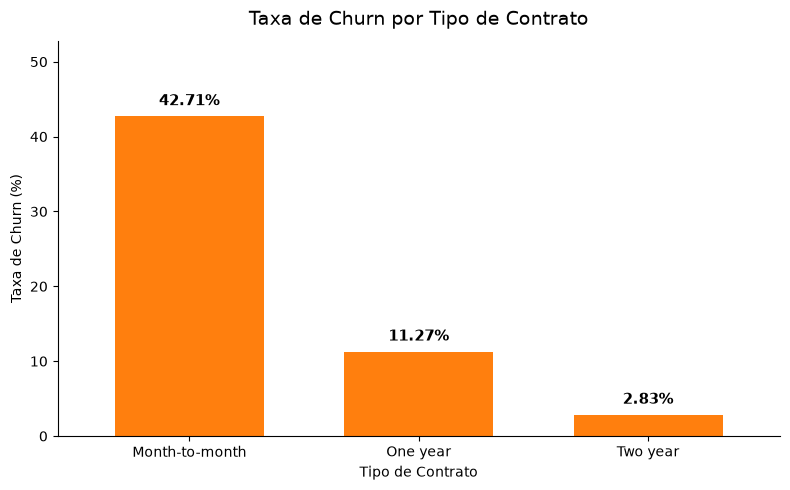

In [11]:
ax = churn_contract.plot(
    kind="bar",
    figsize=(8, 5),
    color="#ff7f0e",
    width=0.65
)

ax.set_title("Taxa de Churn por Tipo de Contrato", fontsize=14, pad=12)
ax.set_xlabel("Tipo de Contrato")
ax.set_ylabel("Taxa de Churn (%)")
ax.tick_params(axis="x", rotation=0)

ax.set_ylim(0, churn_contract.max() + 10)

for i, valor in enumerate(churn_contract):
    ax.text(
        i,
        valor + 1,
        f"{valor:.2f}%",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## Insight — Churn por Tipo de Contrato

Existe uma forte associação entre o tipo de contrato e o churn.

Clientes com contrato **Month-to-month** apresentam taxa de churn de **42,71%**, muito superior aos clientes com contrato **One year (11,27%)** e **Two year (2,83%)**.

O resultado indica que clientes com contratos de maior duração apresentam maior retenção, enquanto clientes no modelo mensal representam o principal grupo de risco.

> **Hipótese de negócio:** clientes com contrato mensal podem apresentar menor compromisso com a empresa e, consequentemente, maior propensão ao cancelamento.

Essa hipótese será investigada em conjunto com outras características dos clientes nas próximas análises.

In [12]:
# Clientes mais novos apresentam maior risco de cancelamento?

df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=[-1, 12, 24, 48, 72],
    labels=[
        "0-12 meses",
        "13-24 meses",
        "25-48 meses",
        "49-72 meses"
    ]
)

In [13]:
# Calcular a taxa de churn

churn_tenure = (
    pd.crosstab(
        df["TenureGroup"],
        df["Churn"],
        normalize="index"
    )["Yes"]
    .mul(100)
)

churn_tenure

TenureGroup
0-12 meses     47.438243
13-24 meses    28.710938
25-48 meses    20.388959
49-72 meses     9.513176
Name: Yes, dtype: float64

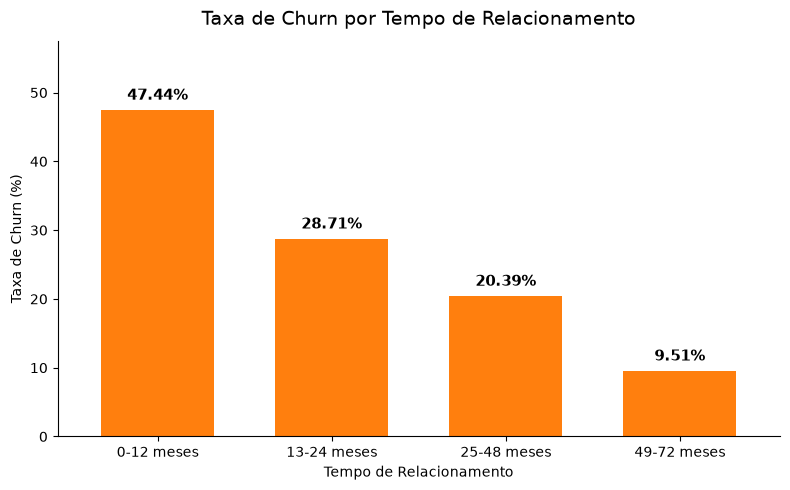

In [14]:
ax = churn_tenure.plot(
    kind="bar",
    figsize=(8, 5),
    color="#ff7f0e",
    width=0.65
)

ax.set_title(
    "Taxa de Churn por Tempo de Relacionamento",
    fontsize=14,
    pad=12
)

ax.set_xlabel("Tempo de Relacionamento")
ax.set_ylabel("Taxa de Churn (%)")
ax.tick_params(axis="x", rotation=0)

ax.set_ylim(0, churn_tenure.max() + 10)

for i, valor in enumerate(churn_tenure):
    ax.text(
        i,
        valor + 1,
        f"{valor:.2f}%",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## Insight — Churn por Tempo de Relacionamento

A taxa de churn apresenta uma relação inversa com o tempo de relacionamento.

Clientes com **0–12 meses** apresentam a maior taxa de churn, de **47,44%**. Essa taxa diminui progressivamente para **28,71%** entre 13–24 meses, **20,39%** entre 25–48 meses e chega a **9,51%** entre clientes com 49–72 meses.

O resultado indica que os primeiros meses da relação com a empresa representam um período crítico para retenção.

> **Hipótese de negócio:** clientes novos podem apresentar maior risco de cancelamento devido à menor fidelização e experiência ainda recente com a empresa.

Essa hipótese será combinada com outras características, especialmente o tipo de contrato, para identificar os segmentos de maior risco.

In [15]:
# Churn × Tempo de Relacionamento × Tipo de Contrato

churn_tenure_contract = (
    pd.crosstab(
        [df["TenureGroup"], df["Contract"]],
        df["Churn"],
        normalize="index"
    )["Yes"]
    .mul(100)
)

churn_tenure_contract

TenureGroup  Contract      
0-12 meses   Month-to-month    51.354062
             One year          10.483871
             Two year           0.000000
13-24 meses  Month-to-month    37.720488
             One year           8.121827
             Two year           0.000000
25-48 meses  Month-to-month    32.917706
             One year          10.617761
             Two year           2.189781
49-72 meses  Month-to-month    26.023392
             One year          12.933754
             Two year           3.325416
Name: Yes, dtype: float64

In [16]:
churn_tenure_contract.unstack()

Contract,Month-to-month,One year,Two year
TenureGroup,,,
0-12 meses,51.354062,10.483871,0.000000
13-24 meses,37.720488,8.121827,0.000000
25-48 meses,32.917706,10.617761,2.189781
49-72 meses,26.023392,12.933754,3.325416


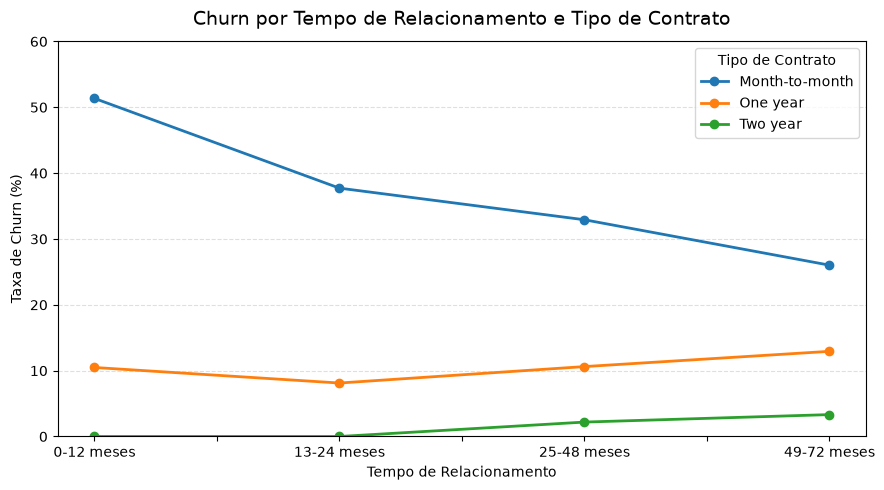

In [17]:
churn_plot = churn_tenure_contract.unstack()

ax = churn_plot.plot(
    kind="line",
    marker="o",
    figsize=(9, 5),
    linewidth=2
)

ax.set_title(
    "Churn por Tempo de Relacionamento e Tipo de Contrato",
    fontsize=14,
    pad=12
)

ax.set_xlabel("Tempo de Relacionamento")
ax.set_ylabel("Taxa de Churn (%)")

ax.set_ylim(0, 60)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

ax.legend(
    title="Tipo de Contrato"
)

plt.tight_layout()
plt.show()

## Insight — Tempo de Relacionamento × Tipo de Contrato

A combinação entre tempo de relacionamento e tipo de contrato revela um padrão consistente.

Clientes com contrato **Month-to-month apresentam a maior taxa de churn em todas as faixas de relacionamento**, variando de **51,35% entre clientes com 0–12 meses** até **26,02% entre clientes com 49–72 meses**.

O grupo de maior risco é formado por clientes com **0–12 meses de relacionamento e contrato Month-to-month**, que apresenta churn de **51,35%**.

Mesmo entre clientes mais antigos, o contrato mensal permanece associado a uma taxa de churn significativamente superior aos contratos de um ou dois anos.

> **Hipótese de negócio:** a combinação entre baixa duração do relacionamento e contrato mensal representa um segmento prioritário para ações de retenção.

Essa combinação deverá ser considerada nas análises posteriores e na definição dos segmentos de maior risco.

In [18]:
# Clientes com mensalidades mais altas apresentam maior risco de churn?
# Criar os grupos de mensalidade

df["MonthlyChargesGroup"] = pd.qcut(
    df["MonthlyCharges"],
    q=3,
    labels=["Baixa", "Média", "Alta"]
)

In [19]:
# Conferir a quantidade de clientes

df["MonthlyChargesGroup"].value_counts().sort_index()

MonthlyChargesGroup
Baixa    2351
Média    2345
Alta     2347
Name: count, dtype: int64

In [20]:
# Taxa de churn por faixa

churn_monthly = (
    pd.crosstab(
        df["MonthlyChargesGroup"],
        df["Churn"],
        normalize="index"
    )["Yes"]
    .mul(100)
)

churn_monthly

MonthlyChargesGroup
Baixa    15.865589
Média    29.680171
Alta     34.086067
Name: Yes, dtype: float64

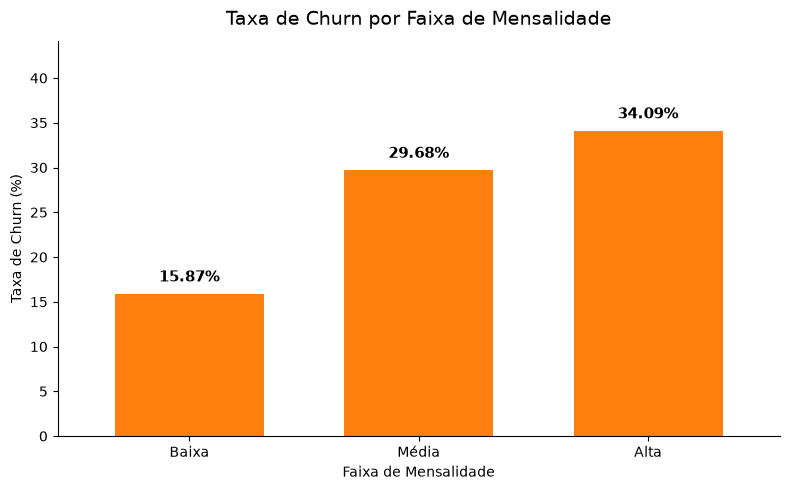

In [21]:
# Gráfico — Churn por faixa de mensalidade

ax = churn_monthly.plot(
    kind="bar",
    figsize=(8, 5),
    color="#ff7f0e",
    width=0.65
)

ax.set_title(
    "Taxa de Churn por Faixa de Mensalidade",
    fontsize=14,
    pad=12
)

ax.set_xlabel("Faixa de Mensalidade")
ax.set_ylabel("Taxa de Churn (%)")
ax.tick_params(axis="x", rotation=0)

ax.set_ylim(0, churn_monthly.max() + 10)

for i, valor in enumerate(churn_monthly):
    ax.text(
        i,
        valor + 1,
        f"{valor:.2f}%",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## Insight — Churn por Faixa de Mensalidade

A taxa de churn aumenta conforme a faixa de mensalidade.

Clientes classificados na faixa **Baixa** apresentam churn de **15,87%**, enquanto clientes da faixa **Média** apresentam **29,68%** e clientes da faixa **Alta**, **34,09%**.

A diferença entre as faixas Baixa e Alta é de aproximadamente **18,22 pontos percentuais**.

O resultado indica uma associação entre mensalidade e churn. Entretanto, esse comportamento pode estar relacionado a outras características dos clientes, como **tipo de contrato e tipo de serviço de internet**.

> **Hipótese de negócio:** clientes com mensalidades mais elevadas podem apresentar maior sensibilidade ao custo ou estar concentrados em serviços e contratos associados a maior churn.

Essa relação será investigada em conjunto com outras variáveis antes de qualquer conclusão causal.

In [22]:
# Churn × Faixa de Mensalidade × Tipo de Contrato
# Calcular a taxa de churn

churn_monthly_contract = (
    pd.crosstab(
        [df["Contract"], df["MonthlyChargesGroup"]],
        df["Churn"],
        normalize="index"
    )["Yes"]
    .mul(100)
)

churn_monthly_contract

Contract        MonthlyChargesGroup
Month-to-month  Baixa                  29.991357
                Média                  44.222834
                Alta                   52.610759
One year        Baixa                   3.950104
                Média                   9.090909
                Alta                   20.038536
Two year        Baixa                   0.981767
                Média                   2.392344
                Alta                    5.496454
Name: Yes, dtype: float64

In [23]:
churn_monthly_contract.unstack()

MonthlyChargesGroup,Baixa,Média,Alta
Contract,,,
Month-to-month,29.991357,44.222834,52.610759
One year,3.950104,9.090909,20.038536
Two year,0.981767,2.392344,5.496454


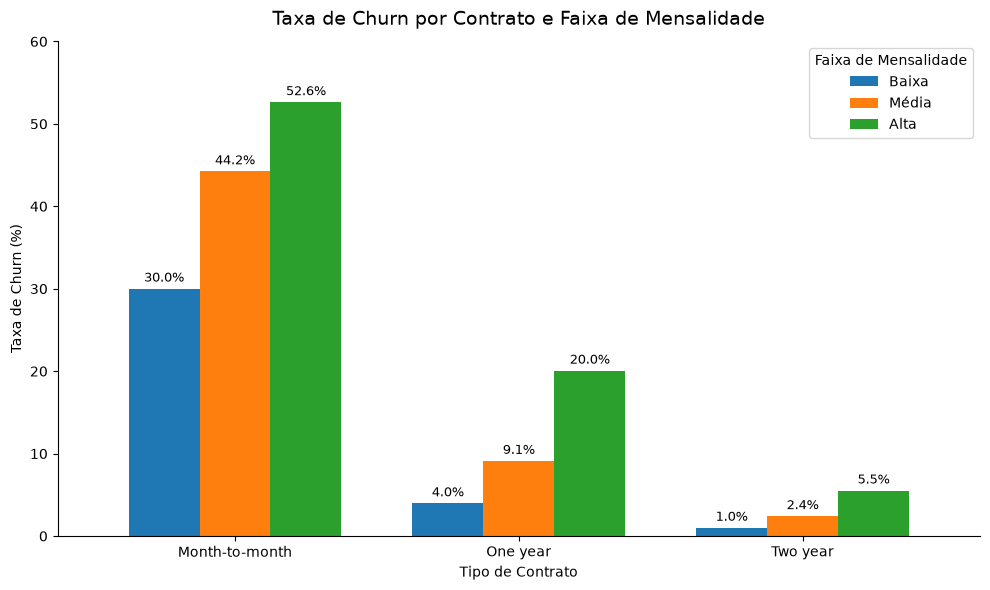

In [24]:
churn_plot = churn_monthly_contract.unstack()

ax = churn_plot.plot(
    kind="bar",
    figsize=(10, 6),
    width=0.75
)

ax.set_title(
    "Taxa de Churn por Contrato e Faixa de Mensalidade",
    fontsize=14,
    pad=12
)

ax.set_xlabel("Tipo de Contrato")
ax.set_ylabel("Taxa de Churn (%)")
ax.tick_params(axis="x", rotation=0)

ax.set_ylim(0, 60)

ax.legend(
    title="Faixa de Mensalidade"
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3,
        fontsize=9
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## Insight — Contrato × Faixa de Mensalidade

A combinação entre tipo de contrato e faixa de mensalidade revela diferenças importantes no comportamento de churn.

Entre clientes com contrato **Month-to-month**, a taxa de churn aumenta de **30,00%** na faixa de mensalidade Baixa para **44,22%** na faixa Média e **52,61%** na faixa Alta.

Nos contratos de **One year** e **Two year**, as taxas permanecem significativamente menores, mesmo entre clientes com mensalidades mais elevadas.

O segmento de maior risco identificado até o momento é, portanto, formado por clientes com **contrato Month-to-month e mensalidade Alta**, que apresenta **52,61% de churn**.

> **Hipótese de negócio:** a combinação entre contrato mensal e maior mensalidade pode representar maior percepção de custo ou menor percepção de valor, tornando esse segmento prioritário para ações de retenção.

Essa associação não implica causalidade. A relação deverá ser analisada em conjunto com outras características, como tipo de serviço e forma de pagamento.

## Insight — Contrato × Faixa de Mensalidade

A combinação entre tipo de contrato e faixa de mensalidade revela diferenças importantes no comportamento de churn.

Entre clientes com contrato **Month-to-month**, a taxa de churn aumenta de **30,00%** na faixa de mensalidade Baixa para **44,22%** na faixa Média e **52,61%** na faixa Alta.

Nos contratos de **One year** e **Two year**, as taxas permanecem significativamente menores, mesmo entre clientes com mensalidades mais elevadas.

O segmento de maior risco identificado até o momento é, portanto, formado por clientes com **contrato Month-to-month e mensalidade Alta**, que apresenta **52,61% de churn**.

> **Hipótese de negócio:** a combinação entre contrato mensal e maior mensalidade pode representar maior percepção de custo ou menor percepção de valor, tornando esse segmento prioritário para ações de retenção.

Essa associação não implica causalidade. A relação deverá ser analisada em conjunto com outras características, como tipo de serviço e forma de pagamento.

In [25]:
# O tipo de serviço de internet está associado a diferentes taxas de churn?
# Calcular a taxa de churn

churn_internet = (
    pd.crosstab(
        df["InternetService"],
        df["Churn"],
        normalize="index"
    )["Yes"]
    .mul(100)
)

churn_internet

InternetService
DSL            18.959108
Fiber optic    41.892765
No              7.404980
Name: Yes, dtype: float64

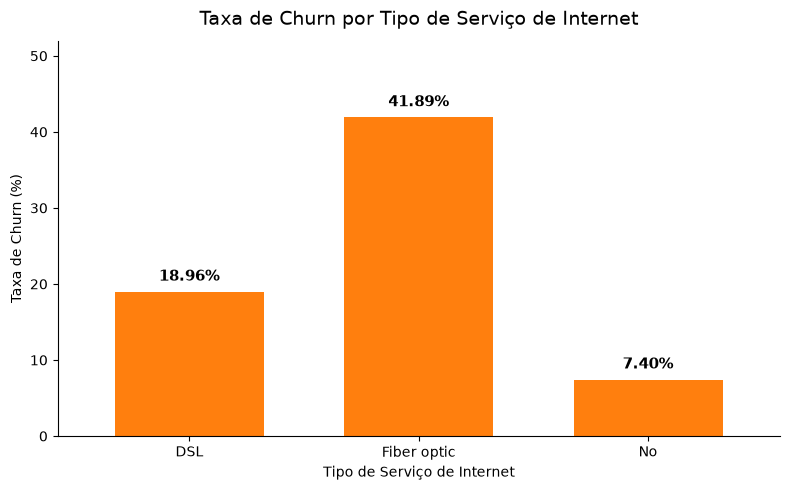

In [26]:
ax = churn_internet.plot(
    kind="bar",
    figsize=(8, 5),
    color="#ff7f0e",
    width=0.65
)

ax.set_title(
    "Taxa de Churn por Tipo de Serviço de Internet",
    fontsize=14,
    pad=12
)

ax.set_xlabel("Tipo de Serviço de Internet")
ax.set_ylabel("Taxa de Churn (%)")
ax.tick_params(axis="x", rotation=0)

ax.set_ylim(0, churn_internet.max() + 10)

for i, valor in enumerate(churn_internet):
    ax.text(
        i,
        valor + 1,
        f"{valor:.2f}%",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## Insight — Churn por Tipo de Serviço de Internet

O tipo de serviço de internet apresenta diferenças relevantes na taxa de churn.

Clientes com serviço **Fiber optic** apresentam churn de **41,89%**, enquanto clientes com **DSL** apresentam **18,96%**. Entre clientes que não possuem serviço de internet, a taxa é de apenas **7,40%**.

O grupo Fiber optic apresenta, portanto, uma taxa de churn significativamente superior aos demais grupos.

> **Hipótese de negócio:** a maior taxa de churn entre clientes Fiber optic pode estar relacionada a fatores como mensalidade, tipo de contrato, percepção de valor ou experiência com o serviço.

Essa relação será investigada em conjunto com outras variáveis antes de estabelecer qualquer conclusão causal.

In [27]:
# Clientes sem OnlineSecurity apresentam maior risco de cancelamento?

churn_security = (
    pd.crosstab(
        df["OnlineSecurity"],
        df["Churn"],
        normalize="index"
    )["Yes"]
    .mul(100)
)

churn_security

OnlineSecurity
No                     41.766724
No internet service     7.404980
Yes                    14.611194
Name: Yes, dtype: float64

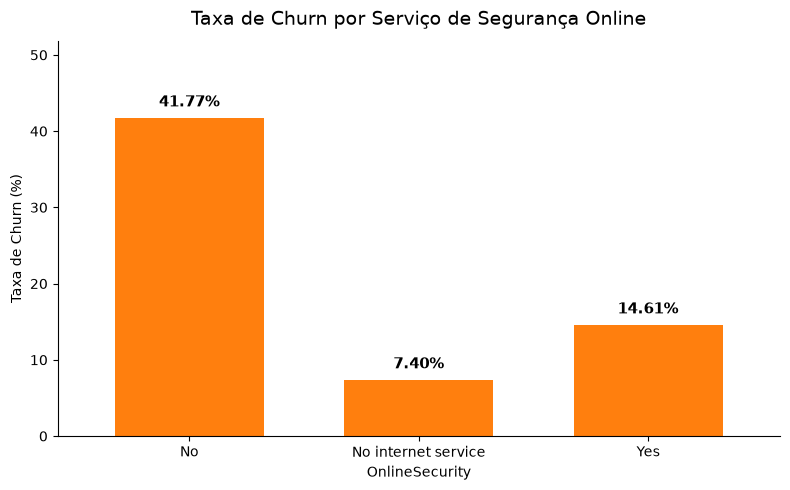

In [28]:
ax = churn_security.plot(
    kind="bar",
    figsize=(8, 5),
    color="#ff7f0e",
    width=0.65
)

ax.set_title(
    "Taxa de Churn por Serviço de Segurança Online",
    fontsize=14,
    pad=12
)

ax.set_xlabel("OnlineSecurity")
ax.set_ylabel("Taxa de Churn (%)")
ax.tick_params(axis="x", rotation=0)

ax.set_ylim(0, churn_security.max() + 10)

for i, valor in enumerate(churn_security):
    ax.text(
        i,
        valor + 1,
        f"{valor:.2f}%",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## Insight — Churn por Serviço de Segurança Online

A presença do serviço de segurança online apresenta uma forte associação com a taxa de churn.

Clientes que possuem serviço de internet, mas **não possuem OnlineSecurity**, apresentam churn de **41,77%**. Entre os clientes que possuem o serviço, a taxa é de **14,61%**.

Clientes sem serviço de internet apresentam churn de **7,40%**.

A diferença entre clientes com e sem OnlineSecurity é de aproximadamente **27,16 pontos percentuais**.

> **Hipótese de negócio:** clientes sem serviços adicionais de proteção podem apresentar menor percepção de valor ou estar concentrados em perfis de maior risco de cancelamento.

Essa associação deverá ser analisada em conjunto com tipo de contrato, serviço de internet e mensalidade antes de estabelecer uma conclusão causal.

In [29]:
# Clientes sem suporte técnico apresentam maior taxa de churn?

churn_techsupport = (
    pd.crosstab(
        df["TechSupport"],
        df["Churn"],
        normalize="index"
    )["Yes"]
    .mul(100)
)

churn_techsupport

TechSupport
No                     41.635474
No internet service     7.404980
Yes                    15.166341
Name: Yes, dtype: float64

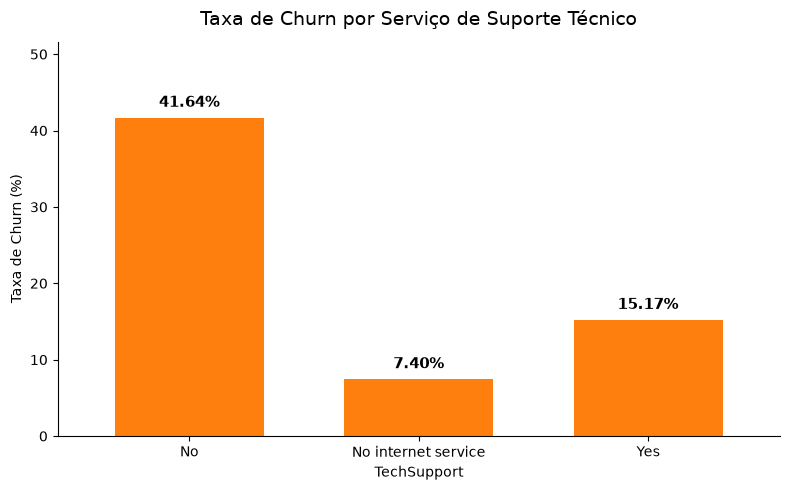

In [30]:
ax = churn_techsupport.plot(
    kind="bar",
    figsize=(8, 5),
    color="#ff7f0e",
    width=0.65
)

ax.set_title(
    "Taxa de Churn por Serviço de Suporte Técnico",
    fontsize=14,
    pad=12
)

ax.set_xlabel("TechSupport")
ax.set_ylabel("Taxa de Churn (%)")
ax.tick_params(axis="x", rotation=0)

ax.set_ylim(0, churn_techsupport.max() + 10)

for i, valor in enumerate(churn_techsupport):
    ax.text(
        i,
        valor + 1,
        f"{valor:.2f}%",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## Insight — Churn por Serviço de Suporte Técnico

A presença do serviço de suporte técnico apresenta uma forte associação com a taxa de churn.

Clientes que possuem serviço de internet, mas **não possuem TechSupport**, apresentam churn de **41,64%**. Entre os clientes que possuem o serviço, a taxa é de **15,17%**.

Clientes sem serviço de internet apresentam churn de **7,40%**.

A diferença entre clientes com e sem TechSupport é de aproximadamente **26,47 pontos percentuais**.

> **Hipótese de negócio:** clientes sem suporte técnico podem apresentar menor percepção de valor ou maior exposição a problemas relacionados ao serviço, aumentando o risco de cancelamento.

Essa associação deverá ser analisada em conjunto com outras características antes de estabelecer uma conclusão causal.

In [31]:
# Existe diferença significativa de churn entre as formas de pagamento?

churn_payment = (
    pd.crosstab(
        df["PaymentMethod"],
        df["Churn"],
        normalize="index"
    )["Yes"]
    .mul(100)
)

churn_payment

PaymentMethod
Bank transfer (automatic)    16.709845
Credit card (automatic)      15.243101
Electronic check             45.285412
Mailed check                 19.106700
Name: Yes, dtype: float64

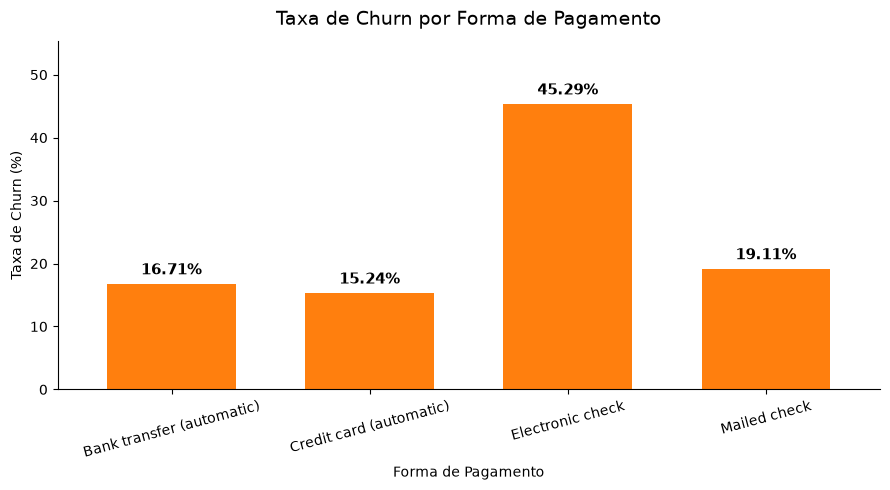

In [32]:
ax = churn_payment.plot(
    kind="bar",
    figsize=(9, 5),
    color="#ff7f0e",
    width=0.65
)

ax.set_title(
    "Taxa de Churn por Forma de Pagamento",
    fontsize=14,
    pad=12
)

ax.set_xlabel("Forma de Pagamento")
ax.set_ylabel("Taxa de Churn (%)")
ax.tick_params(axis="x", rotation=15)

ax.set_ylim(0, churn_payment.max() + 10)

for i, valor in enumerate(churn_payment):
    ax.text(
        i,
        valor + 1,
        f"{valor:.2f}%",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## Insight — Churn por Forma de Pagamento

A forma de pagamento apresenta diferenças relevantes na taxa de churn.

Clientes que utilizam **Electronic check** apresentam churn de **45,29%**, significativamente superior às demais formas de pagamento.

Entre os pagamentos automáticos, as taxas são menores: **16,71%** para Bank transfer (automatic) e **15,24%** para Credit card (automatic).

> **Hipótese de negócio:** clientes que utilizam Electronic check podem apresentar maior risco de churn devido a características do perfil de contratação, menor automatização do pagamento ou concentração em contratos Month-to-month.

Essa associação não implica causalidade e deverá ser investigada em conjunto com o tipo de contrato e outras características do cliente.

In [33]:
# O Electronic check continua apresentando alto churn dentro de cada tipo de contrato?

churn_payment_contract = (
    pd.crosstab(
        [df["Contract"], df["PaymentMethod"]],
        df["Churn"],
        normalize="index"
    )["Yes"]
    .mul(100)
)

churn_payment_contract.unstack()

PaymentMethod,Bank transfer (automatic),Credit card (automatic),Electronic check,Mailed check
Contract,,,,
Month-to-month,34.125637,32.780847,53.729730,31.578947
One year,9.718670,10.301508,18.443804,6.824926
Two year,3.368794,2.237522,7.738095,0.785340


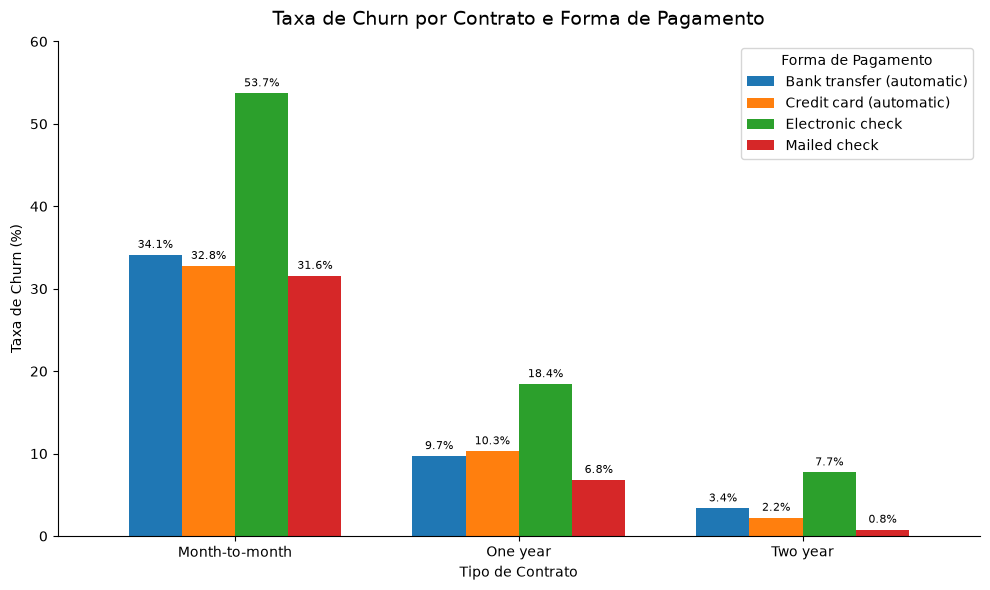

In [34]:
churn_plot = churn_payment_contract.unstack()

ax = churn_plot.plot(
    kind="bar",
    figsize=(10, 6),
    width=0.75
)

ax.set_title(
    "Taxa de Churn por Contrato e Forma de Pagamento",
    fontsize=14,
    pad=12
)

ax.set_xlabel("Tipo de Contrato")
ax.set_ylabel("Taxa de Churn (%)")
ax.tick_params(axis="x", rotation=0)

ax.set_ylim(0, 60)

ax.legend(
    title="Forma de Pagamento"
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3,
        fontsize=8
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## Insight — Contrato × Forma de Pagamento

A combinação entre tipo de contrato e forma de pagamento revela diferenças importantes na taxa de churn.

O segmento de maior risco é formado por clientes com contrato **Month-to-month** que utilizam **Electronic check**, apresentando churn de **53,73%**.

Entre clientes com contrato Month-to-month, as demais formas de pagamento apresentam taxas inferiores: **34,13%** para Bank transfer, **32,78%** para Credit card e **31,58%** para Mailed check.

O padrão também permanece nos contratos de maior duração. O Electronic check apresenta churn de **18,44%** no contrato One year e **7,74%** no contrato Two year.

> **Hipótese de negócio:** a combinação entre contrato mensal e Electronic check representa um segmento prioritário para ações de retenção.

Essa associação não implica causalidade. Outros fatores, como mensalidade, tempo de relacionamento, serviço de internet e serviços adicionais, também devem ser considerados.

In [37]:
"TenureGroup" in df.columns

True

In [38]:
perfil_critico = (
    (df["Contract"] == "Month-to-month") &
    (df["TenureGroup"] == "0-12 meses") &
    (df["OnlineSecurity"] == "No") &
    (df["TechSupport"] == "No")
)

df["PerfilRisco"] = perfil_critico.map({
    True: "Perfil crítico",
    False: "Demais clientes"
})

In [39]:
df["PerfilRisco"].value_counts()

PerfilRisco
Demais clientes    5855
Perfil crítico     1188
Name: count, dtype: int64

In [40]:
churn_risco = (
    pd.crosstab(
        df["PerfilRisco"],
        df["Churn"],
        normalize="index"
    )["Yes"]
    .mul(100)
)

churn_risco

PerfilRisco
Demais clientes    18.838599
Perfil crítico     64.478114
Name: Yes, dtype: float64

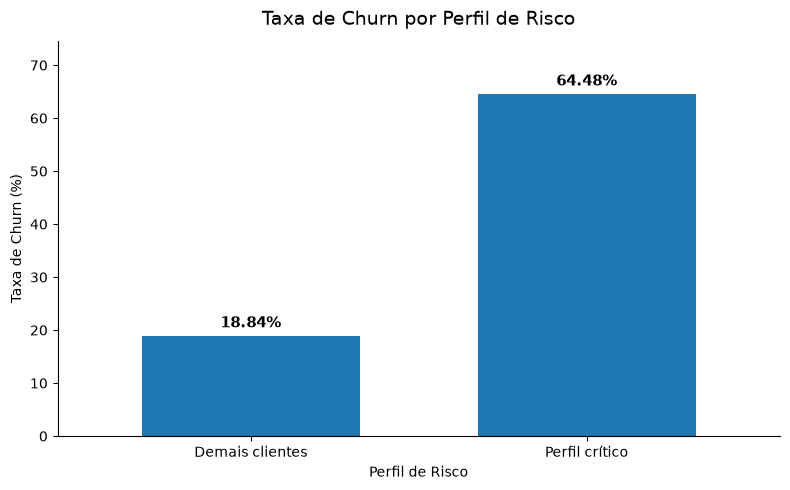

In [41]:
# Gráfico — Churn por Perfil de Risco

ax = churn_risco.plot(
    kind="bar",
    figsize=(8, 5),
    width=0.65
)

ax.set_title(
    "Taxa de Churn por Perfil de Risco",
    fontsize=14,
    pad=12
)

ax.set_xlabel("Perfil de Risco")
ax.set_ylabel("Taxa de Churn (%)")
ax.tick_params(axis="x", rotation=0)

ax.set_ylim(0, churn_risco.max() + 10)

for i, valor in enumerate(churn_risco):
    ax.text(
        i,
        valor + 1,
        f"{valor:.2f}%",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## Insight — Perfil de Risco

A combinação de características permite identificar um segmento de clientes com risco significativamente maior de churn.

O **Perfil crítico** é composto por clientes com:

- contrato **Month-to-month**;
- tempo de relacionamento de **0–12 meses**;
- **sem OnlineSecurity**;
- **sem TechSupport**.

Esse grupo apresenta uma taxa de churn de **64,48%**, enquanto os demais clientes apresentam **18,84%**.

A diferença de aproximadamente **45,64 pontos percentuais** evidencia que a combinação de características é mais informativa do que a análise isolada de uma única variável.

> **Hipótese de negócio:** clientes que apresentam simultaneamente essas características devem ser considerados um segmento prioritário para ações preventivas de retenção.

O resultado representa uma associação observada na base e não uma relação causal. A definição de ações de retenção deverá considerar também aspectos financeiros e operacionais.

In [42]:
pd.crosstab(
    df["PerfilRisco"],
    df["Churn"]
)

Churn,No,Yes
PerfilRisco,,
Demais clientes,4752,1103
Perfil crítico,422,766


# Síntese da Análise Exploratória — Principais Achados

A análise exploratória identificou diferentes características associadas à ocorrência de churn na base de clientes.

## Principais fatores identificados

### 1. Tipo de contrato
Clientes com contrato **Month-to-month** apresentam churn de **42,71%**, significativamente superior aos contratos One year (**11,27%**) e Two year (**2,83%**).

### 2. Tempo de relacionamento
Clientes com **0–12 meses** de relacionamento apresentam churn de **47,44%**, indicando maior concentração de cancelamentos entre clientes recentes.

### 3. Faixa de mensalidade
A taxa de churn aumenta conforme a faixa de mensalidade:
- Baixa → **15,87%**
- Média → **29,68%**
- Alta → **34,09%**

### 4. Serviço de Internet
Clientes com **Fiber optic** apresentam churn de **41,89%**, superior aos clientes com DSL (**18,96%**) e sem serviço de internet (**7,40%**).

### 5. Serviços adicionais
A ausência de serviços como **OnlineSecurity** e **TechSupport** está associada a taxas de churn superiores a 40%.

- Sem OnlineSecurity → **41,77%**
- Com OnlineSecurity → **14,61%**
- Sem TechSupport → **41,64%**
- Com TechSupport → **15,17%**

### 6. Forma de pagamento
Clientes que utilizam **Electronic check** apresentam churn de **45,29%**, enquanto as demais formas apresentam taxas inferiores.

### 7. Combinação de fatores
A análise combinada mostrou que clientes com contrato **Month-to-month** e pagamento por **Electronic check** apresentam churn de **53,73%**.

### 8. Perfil crítico
Foi criado um perfil combinando:

- Contract = Month-to-month
- TenureGroup = 0–12 meses
- OnlineSecurity = No
- TechSupport = No

Esse grupo possui **1.188 clientes**, dos quais **766 cancelaram**, resultando em uma taxa de churn de **64,48%**.

Os demais clientes apresentam churn de apenas **18,84%**.

## Conclusão da EDA

Os resultados indicam que o churn está especialmente associado a clientes com **contratos de curta duração, pouco tempo de relacionamento, maior mensalidade e ausência de determinados serviços adicionais**.

A combinação dessas características permite identificar segmentos prioritários para ações de retenção.

> **Importante:** os resultados representam associações observadas na base de dados e não devem ser interpretados como relações causais.

In [43]:
# Criar variável alvo para o modelo
df_model = df.copy()

df_model["ChurnFlag"] = (
    df_model["Churn"]
    .map({
        "No": 0,
        "Yes": 1
    })
    .astype(int)
)

df_model[["Churn", "ChurnFlag"]].head()

,Churn,ChurnFlag
0,No,0
1,No,0
2,Yes,1
3,No,0
4,Yes,1


In [44]:
df_model["ChurnFlag"].value_counts()

ChurnFlag
0    5174
1    1869
Name: count, dtype: int64

In [45]:
df_model["ChurnFlag"].isna().sum()

np.int64(0)

In [46]:
df["SeniorCitizen"].value_counts()

SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64

In [47]:
churn_senior = (
    pd.crosstab(
        df["SeniorCitizen"],
        df["Churn"],
        normalize="index"
    )["Yes"]
    .mul(100)
)

churn_senior

SeniorCitizen
0    23.606168
1    41.681261
Name: Yes, dtype: float64

In [48]:
df["SeniorCitizen"].value_counts()

SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64

In [49]:
churn_senior = (
    pd.crosstab(
        df["SeniorCitizen"],
        df["Churn"],
        normalize="index"
    )["Yes"]
    .mul(100)
)

churn_senior

SeniorCitizen
0    23.606168
1    41.681261
Name: Yes, dtype: float64

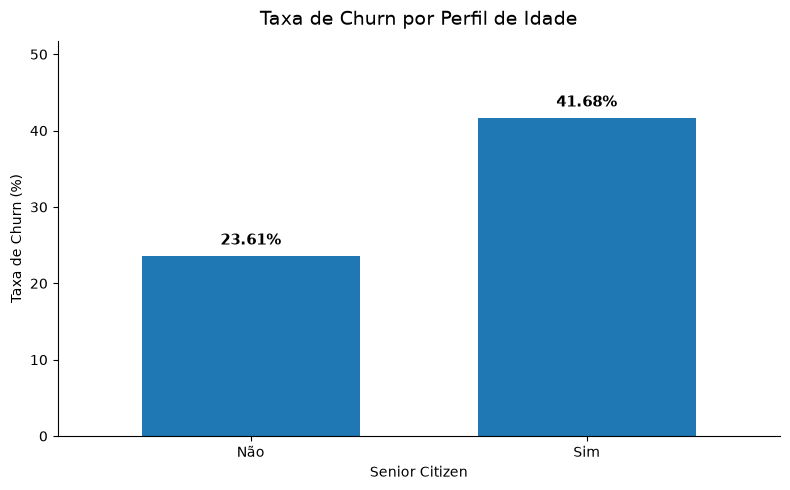

In [50]:
# Gráfico — Churn por SeniorCitizen

churn_senior_plot = churn_senior.rename({
    0: "Não",
    1: "Sim"
})

ax = churn_senior_plot.plot(
    kind="bar",
    figsize=(8, 5),
    width=0.65
)

ax.set_title(
    "Taxa de Churn por Perfil de Idade",
    fontsize=14,
    pad=12
)

ax.set_xlabel("Senior Citizen")
ax.set_ylabel("Taxa de Churn (%)")
ax.tick_params(axis="x", rotation=0)

ax.set_ylim(0, churn_senior_plot.max() + 10)

for i, valor in enumerate(churn_senior_plot):
    ax.text(
        i,
        valor + 1,
        f"{valor:.2f}%",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## Insight — Churn por Perfil de Idade

Clientes classificados como `SeniorCitizen = 1` apresentam uma taxa de churn de **41,68%**, enquanto os demais clientes apresentam **23,61%**.

A diferença de **18,07 pontos percentuais** indica uma associação relevante entre essa característica e o churn.

> **Hipótese de negócio:** clientes idosos podem apresentar necessidades específicas de atendimento, suporte ou adequação dos serviços, o que pode contribuir para uma maior propensão ao cancelamento.

Essa associação não implica causalidade e deve ser analisada em conjunto com outras características do cliente.